# Briefer-than-brief: Efficiency estimation through parameter recovery

In [2]:
import btb
import numpy as np
from scipy.ndimage import gaussian_filter1d
import matplotlib.pyplot as plt


In [3]:
# tolerance for parameter misspecification
frame_rate = 480
stim_dur = 0.5
times = np.linspace(0, stim_dur, round(stim_dur*frame_rate))

vir_tau = 0.0050 # fixed tau
real_taus = np.linspace(vir_tau/1.5, vir_tau*1.5, num=100)
speedups = np.array([1, 1.25, 1.5, 2, 2.5, 3])

assumed_vir = btb.adelson_bergen_vir(times, tau=vir_tau) / frame_rate
stim = btb.generate_stim(times, isi=0, pulse_duration=4, sigma=1.5)

measured_speedup = np.empty((len(speedups), len(real_taus)))
for s in range(0, len(speedups)):
    stim_btb, sf = btb.generate_btb(stim, times, vir_tau, speedup=speedups[s])
    
    for i in range(0, len(real_taus)):
        vir = btb.adelson_bergen_vir(times, tau=real_taus[i]) / frame_rate
        vir = np.roll(vir, int(len(times)/2))
    
        stim_response = np.convolve(stim, vir, mode='same')
        btb_response = np.convolve(stim_btb, vir, mode='same')
    
        popt = btb.fit_visual_response(stim, btb_response)
        measured_speedup[s,i] = real_taus[i] / popt[0]


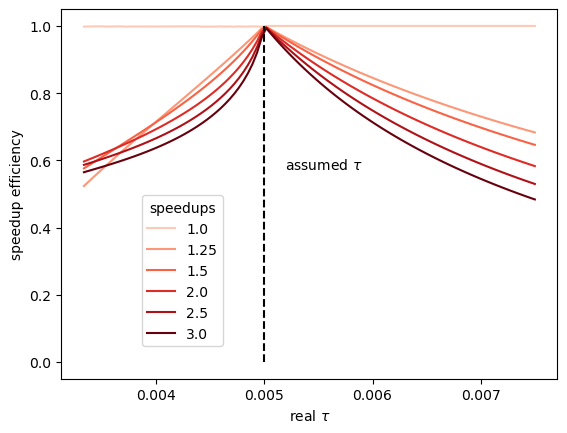

In [4]:
fig, ax = plt.subplots(1, 1)
colors = plt.cm.Reds(np.linspace(0.2, 1, measured_speedup.shape[0]))

for i in range(0, measured_speedup.shape[0]):
    ax.plot(real_taus, 
            (measured_speedup[i,:].T-0.999) / (speedups[i]-0.999), # make sure ratio-scale (speedup = 1 --> 0)
            color=colors[i])

ax.set_xlabel(r'real $\tau$')
ax.set_ylabel('speedup efficiency')

#ax.set_ylim([0, 1.05])

ax.vlines(x=vir_tau, ymin=0, ymax=1., color='black', ls='dashed')
#ax.hlines(y=0.5, xmin=np.min(real_taus), xmax=np.max(real_taus), color='black', ls='dashed')

ax.text(0.45, 0.6, r'assumed $\tau$', color='black', 
        transform=ax.transAxes, fontsize=10, va='top', ha='left')

fig.legend(labels=speedups, title='speedups', loc=[0.25, 0.2])
fig.savefig('efficiency_speedups.png', dpi=600)

measured tau = 0.002363
measured speedup = 1.692536


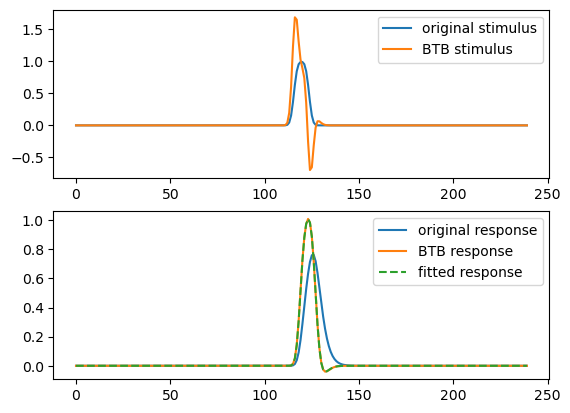

In [5]:
speedup = 2
real_tau = vir_tau/1.25
stim_btb, sf = btb.generate_btb(stim, times, vir_tau, speedup=speedup)

vir = btb.adelson_bergen_vir(times, tau=real_tau) / frame_rate
vir = np.roll(vir, int(len(times)/2))

stim_response = np.convolve(stim, vir, mode='same')
btb_response = np.convolve(stim_btb, vir, mode='same')

fig, ax = plt.subplots(2, 1)

ax[0].plot(stim, label='original stimulus')
ax[1].plot(stim_response, label='original response')

ax[0].plot(stim_btb, label='BTB stimulus')
ax[1].plot(btb_response, label='BTB response')

from scipy.optimize import curve_fit

popt = btb.fit_visual_response(stim, btb_response)

print('measured tau = {:f}'.format(popt[0]))
print('measured speedup = {:f}'.format(real_tau/popt[0]))

ax[1].plot(btb.visual_response(stim, *popt), '--', label='fitted response')
ax[0].legend()
ax[1].legend()